
# Causal Inference — Lab 1: Introduction

1. Tell a **descriptive** question apart from a **causal** one.
2. Write an outcome in the **all-causes / potential-outcomes** notation $Y_i(s,u)$.
3. Explain the **Fundamental Problem of Causal Inference** in one sentence.
4. Walk through the **three steps** of any causal analysis: **define → identify → estimate**.
5. See *in code* why **randomization** is what lets us estimate a causal effect.




| Lecture slide | Section below |
|---|---|
| Descriptive vs Causal questions | **1** |
| All-causes model, $Y_i(s,u)$, causal effect | **2** |
| Defining the causal parameter (ATE) | **3–4** |
| Fundamental Problem of Causal Inference | **3.3** |
| The 3 steps · Identification ($S \perp U$) | **5–6** |
| Estimation · conditional sample means · CLT | **7** |



## 0. Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid")
np.random.seed(42)   # makes every random result below reproducible



## 1. Descriptive vs. Causal questions

- A **descriptive** question asks *how the world actually is* — the realized state.
  *"What is the average grade in this class?"*
- A **causal** question asks *how the world would be under a different condition* — a
  potential (counterfactual) state.
  *"How much higher would a student's grade be **if** they attended class regularly?"*

The whole course is about answering the second kind rigorously. Our running example:

> **A professor wants to know the effect of attending class on grades** to know what *causes* a grade to go up.



## 2. The all-causes model (notation)

We model a student's grade as

$$Y_i(s,u)$$

- $i$ — an individual student (the unit of observation).
- $s$ — the **treatment** . Here $s=1$ = *attends regularly*, $s=0$ = *doesn't*.
- $u$ — **everything else** that affects the grade (study habits, prior knowledge, motivation…).

The **causal effect** of attending, for student $i$, is the difference between the two
potential outcomes:

$$Y_i(1,u) - Y_i(0,u)$$

i.e. *the same student's* grade if they attend minus their grade if they don't.



## 3. What is the average grade?
 We'll simulate a class of 1000 students whose grades are roughly Normal.


In [2]:
# Simulate a population of students and their (observed) grades
n_students = 1000
mean_grade, sd_grade = 75, 12

grades = np.random.normal(mean_grade, sd_grade, n_students)
df = pd.DataFrame({"Grade": grades})
df.head()


,Grade
0,80.960570
1,73.340828
2,82.772262
3,93.276358
4,72.190160


Let's look at the distribution and the single number that answers the descriptive question.


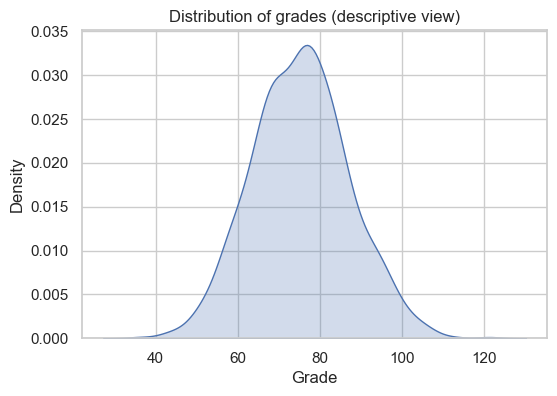

Average grade in the course: 75.23


In [3]:
plt.figure(figsize=(6, 4))
sns.kdeplot(df["Grade"], fill=True)
plt.title("Distribution of grades (descriptive view)")
plt.xlabel("Grade"); plt.ylabel("Density")
plt.show()

print(f"Average grade in the course: {df['Grade'].mean():.2f}")



### 3.3 The Fundamental Problem of Causal Inference 

We now know the average grade. But we still can't say what attendance *does*, because for
each student we only ever see whether they attended or they
didn't. We never see the *same* student's grade under the other choice.

The **counterfactual** is missing: $Y_i(s',u)$ for the state that didn't happen
— is the **Fundamental Problem of Causal Inference**:

$$\text{We observe } Y_i(s,u)\ \text{but never } Y_i(s',u)\ \text{for the same } i.$$



## 4. A "perfect world": Imagine you can see *both* potential outcomes

Imagine a dataset where we *do* observe both $Y_i(1,u)$ and
$Y_i(0,u)$ for every student. We'll assume:

1. **Both states are visible** for every student (impossible in reality).
2. **No confounding** — attendance is the only thing that changes.
3. Say attendance adds a constant boost of **+10 points**.

The parameter we care about is the **Average Treatment Effect**:

$$\text{ATE} = \mathbb{E}[Y_i(1,u)] - \mathbb{E}[Y_i(0,u)]$$


In [4]:
# Build both potential outcomes for every student
true_effect = 10

Y0 = df["Grade"].to_numpy()          # grade if they DON'T attend  = Y_i(0, u)
Y1 = Y0 + true_effect                # grade if they DO attend     = Y_i(1, u)

perfect = pd.DataFrame({
    "Student": np.arange(1, n_students + 1),
    "Y0_no_attend": Y0,
    "Y1_attend":    Y1,
    "Individual_effect": Y1 - Y0,    # = 10 for everyone, by construction
})
perfect.head()


,Student,Y0_no_attend,Y1_attend,Individual_effect
0,1,80.960570,90.960570,10.0
1,2,73.340828,83.340828,10.0
2,3,82.772262,92.772262,10.0
3,4,93.276358,103.276358,10.0
4,5,72.190160,82.190160,10.0


Because we can see both columns, the ATE is just the difference of the two column means.


In [5]:
ate = perfect["Y1_attend"].mean() - perfect["Y0_no_attend"].mean()
print(f"E[Y(1)] = {perfect['Y1_attend'].mean():.2f}")
print(f"E[Y(0)] = {perfect['Y0_no_attend'].mean():.2f}")
print(f"ATE     = {ate:.2f}  (attending raises the average grade by this much)")


E[Y(1)] = 85.23
E[Y(0)] = 75.23
ATE     = 10.00  (attending raises the average grade by this much)


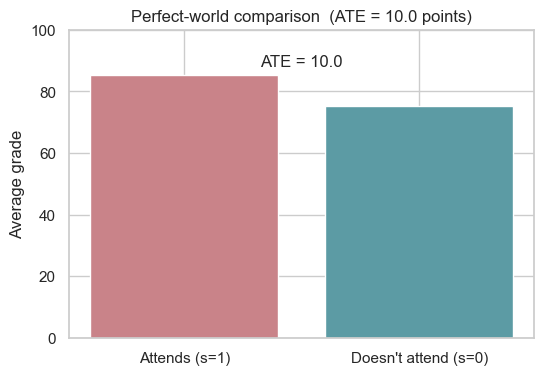

In [7]:
plt.figure(figsize=(6, 4))
means = [perfect["Y1_attend"].mean(), perfect["Y0_no_attend"].mean()]
labels = ["Attends (s=1)", "Doesn't attend (s=0)"]
plt.bar(labels, means, color=["#c98389", "#5c9ba4"])          # <-- changed line
plt.ylim(0, 100); plt.ylabel("Average grade")
plt.title(f"Perfect-world comparison  (ATE = {ate:.1f} points)")
plt.text(0.5, means[0] + 3, f"ATE = {ate:.1f}", ha="center", fontsize=12)
plt.show()


## 5. The three steps when we can't see the counterfactual

Every causal analysis has the same skeleton (from the lecture):

1. **Define** the target parameter: e.g. the ATE for a population. *(done in §4)*
2. **Identify**: show the parameter can be written using things we *can* estimate from
   the data we actually have.
3. **Estimate**: compute it from a finite sample, with a measure of uncertainty.

In reality we only observe, for each student, the outcome under the state they were in:

$$\mathbb{E}[Y(1,U)\mid S=1] \quad\text{and}\quad \mathbb{E}[Y(0,U)\mid S=0].$$



## 6. Identification and randomization 

We can only measure the ATE if one thing is true: whether a student attends
has nothing to do with the other things that affect their grade (motivation,
ability, prior prep, and so on). In symbols:

$$S \perp U$$

"attendance $S$ is independent of all other factors $U$."

If attenders and non-attenders are alike in every *other* way, then:

- the attenders show us what everyone's grade would look like **with** attendance, and
- the non-attenders show us what everyone's grade would look like **without** it.

Attenders and non-attenders are assumed to have the same average potential outcomes: meaning the non-attenders show us what the attenders *would* have scored without attending, and vice versa, so any gap in their grades is due to attendance alone. 

**Randomization delivers this by balancing every other factor (like motivation) across the two groups on average, which is why the naive difference recovers the true ATE.

$$\mathbb{E}[Y(1,U)\mid S=1] = \mathbb{E}[Y(1,U)], \qquad
  \mathbb{E}[Y(0,U)\mid S=0] = \mathbb{E}[Y(0,U)].$$

So we can just **subtract the two group averages** and that difference is the ATE.

The catch: this only works when attendance is assigned *fairly* — for example, at
random. If motivated students choose to attend more, the two groups differ for
reasons that have nothing to do with attendance, and the simple subtraction gives
the wrong answer.

We can test both cases in code. We add a hidden factor — **motivation** ($u$) —
that pushes grades up, then compare two worlds:

- **random attendance** (a coin flip, unrelated to motivation), and
- **confounded attendance** (motivated students attend more often).

In [8]:
rng = np.random.default_rng(0)
n = 20000
true_effect = 10

# Hidden factor u = motivation. It raises the baseline grade.
motivation = rng.normal(0, 1, n)
Y0 = 70 + 8 * motivation + rng.normal(0, 5, n)   # grade if NOT attending
Y1 = Y0 + true_effect                            # attending adds exactly 10

def naive_estimate(S):
    # Difference in observed group means: mean(Y | attend) - mean(Y | not)
    Y_obs = np.where(S == 1, Y1, Y0)             # we only see one column per person
    return Y_obs[S == 1].mean() - Y_obs[S == 0].mean()

# (a) RANDOM assignment: coin flip, independent of motivation  ->  S ⟂ U holds
S_random = rng.binomial(1, 0.5, n)

# (b) CONFOUNDED assignment: motivated students attend more    ->  S ⟂ U fails
p_attend = 1 / (1 + np.exp(-2 * motivation))     # logistic in motivation
S_confounded = rng.binomial(1, p_attend)

print(f"True ATE (by construction):          {true_effect:.2f}")
print(f"Naive estimate — RANDOM assignment:  {naive_estimate(S_random):.2f}")
print(f"Naive estimate — CONFOUNDED:         {naive_estimate(S_confounded):.2f}")


True ATE (by construction):          10.00
Naive estimate — RANDOM assignment:  10.11
Naive estimate — CONFOUNDED:         19.68



**Results**

- Under **random** assignment the naive difference ≈ **10**: randomization forces
  $S \perp U$, so the comparison is apples-to-apples and the ATE is *identified*.
- Under **confounding** the naive difference is **too big**: attenders were already more
  motivated (higher $Y_0$), so we credit attendance for a gap it didn't fully cause, as some of the grade difference is from existing motivation.

This is the whole reason the summer-jobs study in the lecture (Kessler et al. 2022) relied
on a **lottery**: more youths applied than there were jobs, so jobs were handed out at
random — making $S \perp U$ true by design.



## 7. Estimation

Once identified, the estimator is just **conditional sample means**: We take the average grade in each group and subtract them.

$$\widehat{\text{ATE}} = \underbrace{\frac{\sum_i y_i s_i}{\sum_i s_i}}_{\text{mean grade among attenders}}
 \; - \;
 \underbrace{\frac{\sum_i y_i (1-s_i)}{\sum_i (1-s_i)}}_{\text{mean grade among non-attenders}}.$$

We also want to know *how sure* we are. By the Central Limit Theorem the estimator is
approximately Normal, so a rough 95% confidence interval for a normal distribution is
$\widehat{\text{ATE}} \pm 1.96 \times \text{SE}$.


In [9]:
# Use the RANDOMIZED experiment from §6 (where the estimate is valid)
S = S_random
Y_obs = np.where(S == 1, Y1, Y0)
y1, y0 = Y_obs[S == 1], Y_obs[S == 0]

ate_hat = y1.mean() - y0.mean()
# Standard error of a difference in means
se = np.sqrt(y1.var(ddof=1)/len(y1) + y0.var(ddof=1)/len(y0))
lo, hi = ate_hat - 1.96*se, ate_hat + 1.96*se

print(f"Estimated ATE : {ate_hat:.2f}")
print(f"Std. error    : {se:.3f}")
print(f"95% CI        : [{lo:.2f}, {hi:.2f}]  (contains the true 10 ✓)")


Estimated ATE : 10.11
Std. error    : 0.134
95% CI        : [9.85, 10.37]  (contains the true 10 ✓)


Estimated ATE = 10.11, using only the observed grades, we recovered almost the true effect of 10 that was built into the code because assignment was random. 


## Recap & path forward

 **Question → parameter → identification → estimate**:

1. Defined a causal parameter (the ATE).
2. Saw the Fundamental Problem: we never see both potential outcomes for one person.
3. Identified the ATE under $S \perp U$ (guaranteed by randomization).
4. Estimated it with conditional sample means and put a CI around it.
